В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
! ls drive/MyDrive/Colab\ Notebooks/cars.csv
#

'drive/MyDrive/Colab Notebooks/cars.csv'


In [4]:
data = pd.read_csv('drive/MyDrive/Colab Notebooks/cars.csv')
data.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [5]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
#?pd.DataFrame.info

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [8]:
print(data['Transmission'].value_counts())
print(data['Fuel_Type'].value_counts())

Transmission
Automatic    57
Manual       43
Name: count, dtype: int64
Fuel_Type
Petrol    52
Diesel    48
Name: count, dtype: int64


In [9]:
print(data['Brand'].nunique())
print(data['Model'].nunique())

11
58


In [10]:
data['Owner_Type'].value_counts()

,count
Owner_Type,
First,44
Second,43
Third,13


**Висновки**

В наборі даних 8 числових і 5 категоріальних колонок з яких:
- 2 бінарні Fuel_Type, Transmission (по 2 значення)
- 2 мультикатегоріальних (без порядку): Brand (11 значень), Model (58 значень)
- 1 колонкa Owner_Type, в якій можна встановити відношення порядку (3 значення: First < Second < Third)

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [11]:
from sklearn.model_selection import train_test_split


In [12]:
X = data.drop('Price', axis=1)
y = data['Price']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [14]:
X_train

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4
6,7,Mahindra,Scorpio,2018,45000,Diesel,Automatic,Second,15,2179,140,7
27,28,BMW,X3,2019,22000,Diesel,Automatic,Second,18,1995,187,5


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [15]:
print(X_train['Fuel_Type'].value_counts(dropna = False))
print(X_train['Transmission'].value_counts(dropna = False))

Fuel_Type
Petrol    41
Diesel    39
Name: count, dtype: int64
Transmission
Automatic    49
Manual       31
Name: count, dtype: int64


In [17]:
fuel_codes = {'Petrol': 1, 'Diesel': 0}
transmission_codes = {'Automatic': 1, 'Manual': 0}

X_train['Fuel_Type_Code'] = X_train['Fuel_Type'].map(fuel_codes)
X_train['Transmission_Code'] = X_train['Transmission'].map(transmission_codes)

X_test['Fuel_Type_Code'] = X_test['Fuel_Type'].map(fuel_codes)
X_test['Transmission_Code'] = X_test['Transmission'].map(transmission_codes)

In [18]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(X_train[['Brand']])

X_train[enc.categories_[0]] = enc.transform(X_train[['Brand']])
X_test[enc.categories_[0]] = enc.transform(X_test[['Brand']])


In [19]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [20]:
data[['Brand', 'Model']].value_counts()

Brand       Model        
Ford        Mustang          3
Hyundai     Verna            3
Mercedes    C-Class          3
Tata        Altroz           3
BMW         7 Series         2
            3 Series         2
            X5               2
Audi        A6               2
            Q7               2
            A3               2
Hyundai     Santro           2
            Elantra          2
Honda       WR-V             2
            BR-V             2
Ford        EcoSport         2
            Ranger           2
Mercedes    GLE              2
            GLA              2
Mahindra    XUV300           2
            Thar             2
Mercedes    E-Class          2
Maruti      S-Cross          2
Hyundai     Venue            2
Ford        Aspire           2
BMW         X3               2
Audi        A5               2
Volkswagen  T-Roc            2
            Vento            2
            Passat           2
Toyota      Innova Crysta    2
            Yaris            2
Volkswagen  Ameo             2
Tata        Tiago            2
            Safari           2
Toyota      Camry            2
Tata        Tigor            2
Maruti      Vitara           2
Toyota      Fortuner         2
Audi        A4               1
            Q3               1
BMW         5 Series         1
            X1               1
Hyundai     Sonata           1
            Creta            1
Honda       City             1
            Civic            1
Ford        Figo             1
            Endeavour        1
Mahindra    Scorpio          1
Maruti      Swift            1
Tata        Harrier          1
Mercedes    GLC              1
Maruti      Ertiga           1
Tata        Nexon            1
Toyota      Innova           1
            Corolla          1
Volkswagen  Polo             1
            Tiguan           1
Name: count, dtype: int64

In [21]:
# ідея закодувати моделі авто в залежності від класу:

# 5 класів: A / B / C / D / SUV
model_class = {
    "Santro": "A",

    "Tiago": "B",
    "Tigor": "B",
    "Altroz": "B",
    "Swift": "B",
    "Polo": "B",
    "Figo": "B",
    "Ameo": "B",
    "Aspire": "B",
    "Yaris": "B",

    "City": "C",
    "Verna": "C",
    "Civic": "C",
    "Corolla": "C",
    "Vento": "C",

    "Elantra": "D",
    "Sonata": "D",
    "Passat": "D",
    "Camry": "D",
    "Mustang": "D",
    "A3": "D",
    "A4": "D",
    "A5": "D",
    "A6": "D",
    "3 Series": "D",
    "5 Series": "D",
    "7 Series": "D",
    "C-Class": "D",
    "E-Class": "D",

    "WR-V": "SUV",
    "BR-V": "SUV",
    "EcoSport": "SUV",
    "Ranger": "SUV",
    "XUV300": "SUV",
    "Thar": "SUV",
    "S-Cross": "SUV",
    "Venue": "SUV",
    "Vitara": "SUV",
    "Safari": "SUV",
    "Harrier": "SUV",
    "Nexon": "SUV",
    "Scorpio": "SUV",
    "Creta": "SUV",
    "Endeavour": "SUV",
    "Fortuner": "SUV",
    "Tiguan": "SUV",
    "T-Roc": "SUV",
    "GLA": "SUV",
    "GLC": "SUV",
    "GLE": "SUV",
    "X1": "SUV",
    "X3": "SUV",
    "X5": "SUV",
    "Q3": "SUV",
    "Q7": "SUV",
    "Ertiga": "SUV",
    "Innova": "SUV",
    "Innova Crysta": "SUV"
}


In [22]:
X_train['Model_Class'] = X_train['Model'].map(model_class)
X_test['Model_Class'] = X_test['Model'].map(model_class)

model_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
model_encoder.fit(X_train[['Model_Class']])

X_train[model_encoder.get_feature_names_out(["Model_Class"])] = model_encoder.transform(X_train[['Model_Class']])
X_test[model_encoder.get_feature_names_out(["Model_Class"])] = model_encoder.transform(X_test[['Model_Class']])
X_train

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Class,Model_Class_A,Model_Class_B,Model_Class_C,Model_Class_D,Model_Class_SUV
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,...,0.0,0.0,1.0,1.0,SUV,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,...,0.0,0.0,0.0,0.0,D,0.0,0.0,0.0,1.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,...,0.0,0.0,0.0,0.0,D,0.0,0.0,0.0,1.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,1.0,1.0,C,0.0,0.0,1.0,0.0,0.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,...,0.0,0.0,0.0,1.0,SUV,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,...,0.0,0.0,0.0,2.0,B,0.0,1.0,0.0,0.0,0.0
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,...,0.0,0.0,0.0,0.0,D,0.0,0.0,0.0,1.0,0.0
6,7,Mahindra,Scorpio,2018,45000,Diesel,Automatic,Second,15,2179,...,0.0,0.0,0.0,1.0,SUV,0.0,0.0,0.0,0.0,1.0
27,28,BMW,X3,2019,22000,Diesel,Automatic,Second,18,1995,...,0.0,0.0,0.0,1.0,SUV,0.0,0.0,0.0,0.0,1.0


Очікуваний результат після трансформацій:

In [23]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Class,Model_Class_A,Model_Class_B,Model_Class_C,Model_Class_D,Model_Class_SUV
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,SUV,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,D,0.0,0.0,0.0,1.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,D,0.0,0.0,0.0,1.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,C,0.0,0.0,1.0,0.0,0.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Class,Model_Class_A,Model_Class_B,Model_Class_C,Model_Class_D,Model_Class_SUV
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,A,1.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,C,0.0,0.0,1.0,0.0,0.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,SUV,0.0,0.0,0.0,0.0,1.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,B,0.0,1.0,0.0,0.0,0.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [24]:
num_cols = X_train.select_dtypes(include='number').columns

X_train = X_train[num_cols].copy().drop(columns = ['Car_ID'])
X_test = X_test[num_cols].copy().drop(columns = ['Car_ID'])

In [25]:
data_union = pd.concat([X_train, y_train], axis=1)
corr = data_union.corr().round(2)
corr.style.background_gradient()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Class_A,Model_Class_B,Model_Class_C,Model_Class_D,Model_Class_SUV,Price
Year,1.000000,-0.710000,0.280000,-0.390000,-0.250000,-0.280000,0.250000,-0.200000,-0.260000,0.200000,-0.150000,-0.040000,-0.090000,0.180000,0.290000,-0.120000,0.250000,-0.220000,0.020000,-0.010000,0.060000,0.460000,0.010000,-0.290000,-0.080000,-0.230000
Kilometers_Driven,-0.710000,1.000000,-0.130000,0.100000,-0.060000,0.400000,-0.330000,-0.070000,0.100000,-0.250000,-0.010000,0.060000,0.150000,-0.040000,-0.190000,-0.090000,0.030000,0.370000,-0.140000,-0.000000,-0.030000,-0.240000,0.170000,0.010000,0.080000,-0.080000
Mileage,0.280000,-0.130000,1.000000,-0.710000,-0.680000,-0.180000,-0.070000,-0.400000,-0.150000,-0.130000,-0.300000,0.360000,0.220000,0.030000,0.120000,-0.240000,0.350000,-0.200000,0.090000,0.030000,0.100000,0.480000,0.090000,-0.190000,-0.230000,-0.640000
Engine,-0.390000,0.100000,-0.710000,1.000000,0.800000,0.170000,-0.170000,0.460000,0.090000,0.290000,0.180000,-0.150000,-0.180000,-0.020000,-0.190000,0.160000,-0.340000,0.230000,-0.170000,-0.200000,-0.140000,-0.450000,-0.140000,0.270000,0.170000,0.710000
Power,-0.250000,-0.060000,-0.680000,0.800000,1.000000,-0.140000,0.080000,0.590000,0.160000,0.370000,0.240000,-0.190000,-0.170000,-0.120000,-0.220000,0.280000,-0.320000,-0.040000,-0.150000,-0.200000,-0.140000,-0.440000,-0.160000,0.450000,0.000000,0.850000
Seats,-0.280000,0.400000,-0.180000,0.170000,-0.140000,1.000000,-0.410000,-0.070000,0.120000,-0.110000,-0.160000,0.200000,-0.090000,0.010000,-0.080000,-0.110000,-0.010000,0.350000,-0.090000,-0.040000,-0.030000,-0.130000,-0.080000,-0.310000,0.430000,0.000000
Fuel_Type_Code,0.250000,-0.330000,-0.070000,-0.170000,0.080000,-0.410000,1.000000,-0.010000,-0.010000,-0.050000,0.110000,-0.160000,-0.010000,-0.240000,0.150000,-0.050000,0.070000,-0.010000,0.130000,0.280000,0.110000,0.200000,0.150000,-0.040000,-0.200000,-0.110000
Transmission_Code,-0.200000,-0.070000,-0.400000,0.460000,0.590000,-0.070000,-0.010000,1.000000,0.270000,0.280000,-0.120000,-0.220000,0.030000,-0.170000,-0.110000,0.280000,-0.400000,-0.080000,0.160000,0.010000,-0.140000,-0.380000,-0.010000,0.540000,-0.190000,0.680000
Audi,-0.260000,0.100000,-0.150000,0.090000,0.160000,0.120000,-0.010000,0.270000,1.000000,-0.120000,-0.120000,-0.090000,-0.090000,-0.080000,-0.090000,-0.120000,-0.130000,-0.110000,-0.100000,-0.200000,-0.040000,-0.140000,-0.090000,0.310000,-0.140000,0.330000
BMW,0.200000,-0.250000,-0.130000,0.290000,0.370000,-0.110000,-0.050000,0.280000,-0.120000,1.000000,-0.130000,-0.090000,-0.100000,-0.080000,-0.090000,-0.130000,-0.130000,-0.120000,-0.110000,0.010000,-0.040000,-0.150000,-0.090000,0.190000,-0.010000,0.480000


In [26]:
corr_price = data_union.corr()['Price'].drop("Price").round(2)
corr_price[corr_price.abs() > 0.5].sort_values(key=lambda s: s.abs(), ascending=False)


,Price
Power,0.85
Engine,0.71
Transmission_Code,0.68
Mileage,-0.64


**Висновки**

З цільовою змінною Price найбільше корелюють такі ознаки:

- Power (0.85) - чим більше потужність, тим вище ціна
- Engine (0.71) - чим більше обʼєм двигуна, тим вище ціна
- Transmission_Code	(0.68) - автомобілі з коробкою автомат коштують дорожче
- Mileage	(-0.64) - тут кореляція відємна, чим більше пробіг, тим дешевше авто


**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression().fit(X_train, y_train)

prediction_train = lr.predict(X_train)
prediction_test = lr.predict(X_test)

loss_train = np.sqrt(mean_squared_error(y_train, prediction_train))
loss_test = np.sqrt(mean_squared_error(y_test, prediction_test))

print(loss_train, loss_test)


198040.10073474626 240420.5170316034


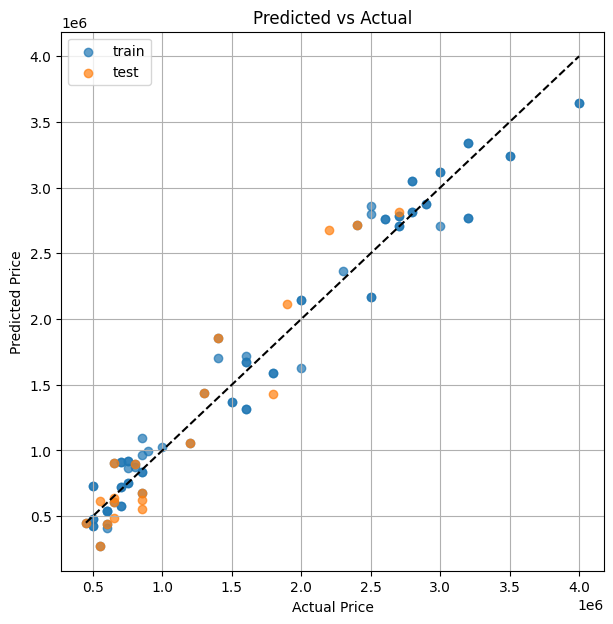

In [28]:
plt.figure(figsize=(7,7))
plt.scatter(y_train, prediction_train, label='train', alpha=0.7)
plt.scatter(y_test,  prediction_test,  label='test',  alpha=0.7)
y_all = np.concatenate([y_train, y_test])
plt.plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()], 'k--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.title('Predicted vs Actual')
plt.show()

**Висновки**

На графіку predicted vs actual точки для train і test переважно лежать вздовж лінії ідеальних прогнозів (Predicted Price = Actual Price), отже модель уловлює основну залежність. Помилка на test вища 240k ніж на train 198k, що вказує погіршення якості на тестових даних, але overfitting невеликий. Найбільший розкид спостерігається для дорогих авто, у цьому діапазоні модель прогнозує менш точно, бо в дорогому сегменті менше прикладів, тому модель гірше узагальнює

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [29]:
from sklearn.preprocessing import StandardScaler

columns_to_scale = X_train.iloc[:, :6].columns.to_list()

scaler = StandardScaler()
scaler.fit(X_train[columns_to_scale])

X_train_scaled = X_train.copy()
X_train_scaled[columns_to_scale] = scaler.transform(X_train[columns_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [30]:
lr_scaled = LinearRegression().fit(X_train_scaled, y_train)

prediction_train_scaled = lr_scaled.predict(X_train_scaled)
prediction_test_scaled = lr_scaled.predict(X_test_scaled)

loss_train_scaled = np.sqrt(mean_squared_error(y_train, prediction_train_scaled))
loss_test_scaled = np.sqrt(mean_squared_error(y_test, prediction_test_scaled))

print(loss_train_scaled, loss_test_scaled)


198040.10073474637 240420.51703159927


In [31]:
weights_df = pd.DataFrame({
    'feature': np.append(X_train_scaled.columns, 'Intercept'),
    'weight': np.append(lr_scaled.coef_, lr_scaled.intercept_)
})
weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).style.format({'weight': '{:.2f}'})

,feature,weight
25,Intercept,1584659.49
8,Audi,813208.22
15,Mercedes,784216.50
9,BMW,693017.33
13,Mahindra,-664046.77
12,Hyundai,-605792.65
4,Power,485038.64
14,Maruti,-455353.78
6,Fuel_Type_Code,-351843.50
21,Model_Class_B,-294920.90


**Висновки**

Цікаво, що перші 5 найвпливовіших коефіцієнтів - бренди авто, дорогі - Audi (813208.22), Mercedes (784216.50), BMW(693017.33) - зі знаком плюс, тобто машини цих брендів в середньому коштують дорожче, а  Mahindra (-664046.77) і Hyundai(-605792.65) зі знаком мінус, тобто авто цих брендів в середньому коштують дешевше. І тільки після цього іде ознака Power	(485038.64)

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [32]:
import statsmodels.api as sm


model = sm.OLS(y_train, sm.add_constant(X_train_scaled))
results = model.fit()
results.params.reset_index().rename(columns={'index': 'feature', 0: 'weight'}). \
  sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).style.format({'weight': '{:.2f}'})


,feature,weight
0,const,1227553.13
9,Audi,924803.96
16,Mercedes,895812.24
10,BMW,804613.07
14,Mahindra,-552451.03
13,Hyundai,-494196.91
21,Model_Class_A,489203.45
5,Power,485038.64
7,Fuel_Type_Code,-351843.50
15,Maruti,-343758.04


In [33]:
pred_sm = results.predict(sm.add_constant(X_train_scaled))
pred_skl = lr_scaled.predict(X_train_scaled)
print(np.max(np.abs(pred_sm - pred_skl)))

5.587935447692871e-09


Отримала різні коеффіцієнти. Хоча при перевірці видно що при різних коефіцієнтах в моделях - вони прогнозують онаковий результат.

Далі пробую натренувати LinearRegression без intercept, а з константою, як в statsmodels:

In [34]:
lr_scaled = LinearRegression(fit_intercept=False).fit(sm.add_constant(X_train_scaled), y_train)

prediction_train_scaled = lr_scaled.predict(sm.add_constant(X_train_scaled))
#prediction_test_scaled = lr_scaled.predict(X_test_scaled)

loss_train_scaled = np.sqrt(mean_squared_error(y_train, prediction_train_scaled))
#loss_test_scaled = np.sqrt(mean_squared_error(y_test, prediction_test_scaled))
print(loss_train_scaled)

198040.10073474643


In [35]:
weights_df = pd.DataFrame({
    'feature': sm.add_constant(X_train_scaled).columns,
    'weight': lr_scaled.coef_
})
weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).style.format({'weight': '{:.2f}'})

,feature,weight
0,const,1227553.13
9,Audi,924803.96
16,Mercedes,895812.24
10,BMW,804613.07
14,Mahindra,-552451.03
13,Hyundai,-494196.91
21,Model_Class_A,489203.45
5,Power,485038.64
7,Fuel_Type_Code,-351843.50
15,Maruti,-343758.04


Помилка не змінилась, але коефіцієнти тепер однакові

In [36]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     63.92
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           3.95e-32
Time:                        12:31:54   Log-Likelihood:                -1089.2
No. Observations:                  80   AIC:                             2226.
Df Residuals:                      56   BIC:                             2284.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.228e+06   7.94e+0

In [37]:
significant_coef = results.pvalues[results.pvalues < 0.05]
significant_coef

,0
const,7.367616e-22
Power,1.300608e-08
Fuel_Type_Code,3.265501e-04
Transmission_Code,2.067523e-02
Audi,4.030777e-12
BMW,2.129563e-10
Hyundai,1.857647e-04
Mahindra,1.526005e-04
Maruti,6.910623e-03
Mercedes,3.386324e-12


**Висновки**

Список ознак, які є стат значущими на рівні значущості 0.05:
- Power
- Fuel_Type_Code
- Transmission_Code
- Audi
- BMW
- Hyundai
- Mahindra
- Maruti
- Mercedes
- Toyota
- Model_Class_A
- Model_Class_C
- Model_Class_D
- Model_Class_SUV

In [38]:
significant_coef.drop('const').index.to_list()

['Power',
 'Fuel_Type_Code',
 'Transmission_Code',
 'Audi',
 'BMW',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Toyota',
 'Model_Class_A',
 'Model_Class_C',
 'Model_Class_D',
 'Model_Class_SUV']

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [39]:
significant_coef_list = significant_coef.drop('const').index.to_list()

model = sm.OLS(y_train, sm.add_constant(X_train_scaled[significant_coef_list]))
results2 = model.fit()
print(results2.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     99.13
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           3.23e-38
Time:                        12:32:14   Log-Likelihood:                -1097.1
No. Observations:                  80   AIC:                             2224.
Df Residuals:                      65   BIC:                             2260.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.194e+06   1.02e+0

**Висновок**

Ні, показники суттєво не змінилися:  R-squared зменшився з 0.963 до 0.955, а Adj. R-squared з 0.948 до 0.946. Це означає, що вилучені ознаки майже не покращували якість моделі.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [40]:
significant_coef_0_25 = results.pvalues[results.pvalues < 0.25].index.drop('const').to_list()

model = sm.OLS(y_train, sm.add_constant(X_train_scaled[significant_coef_0_25]))
results3 = model.fit()
print(results3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     88.81
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           6.31e-37
Time:                        12:32:28   Log-Likelihood:                -1092.1
No. Observations:                  80   AIC:                             2220.
Df Residuals:                      62   BIC:                             2263.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.214e+06   1.06e+0

**Висновки**

- Показники порівняно з завданням 8 суттєво не змінились: R-squared трохи зменшився з 0.963 до 0.961, а Adj. R-squared трохи збільшився 0.948 до 0.950.
- Для використання я б лишила модель із завдання 9 (p<0.05), бо вона простіша й інтерпретованіша, а R-squared зменьшився не значно